# Retail Sales Forecasting with XGBoost
# Overview
This project develops a machine learning model to forecast monthly retail sales using XGBoost. Historical sales data are aggregated to the monthly level and transformed into time-series features such as lagged sales, seasonal indicators, and rolling statistics.

# Objective
The objective is to evaluate whether XGBoost can learn historical and seasonal patterns in retail sales and generate forecasts for future months.



# IMPORT RELEVANT PYTHON AND SCIKIT-LEARN LIBRARIES

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
import warnings
warnings.filterwarnings("ignore")

# IMPORT THE CSV DATA

In [85]:
sales = pd.read_csv(r"C:\Users\H P\Downloads\archive (57)\stores_sales_forecasting.csv", encoding_errors="ignore")
sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


# COPY ORIGINAL DATA AS DF_SALES

In [86]:
df_sales = sales.copy()
df_sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
2117,9965,CA-2016-146374,12/5/2016,12/10/2016,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,...,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320
2118,9981,US-2015-151435,9/6/2015,9/9/2015,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,...,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548
2119,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028


# INSPECT DATA

In [87]:
df_sales.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


In [88]:
df_sales.tail(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2101,9902,CA-2017-117646,8/21/2017,8/25/2017,Standard Class,SC-20845,Sung Chung,Consumer,United States,Louisville,...,80027,West,FUR-FU-10001037,Furniture,Furnishings,"DAX Charcoal/Nickel-Tone Document Frame, 5 x 7",22.7520,3,0.20,7.1100
2102,9904,CA-2014-122609,11/12/2014,11/18/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Carrollton,...,75007,Central,FUR-FU-10004587,Furniture,Furnishings,"GE General Use Halogen Bulbs, 100 Watts, 1 Bul...",25.1280,3,0.60,-6.9102
2103,9906,US-2015-129007,9/13/2015,9/15/2015,First Class,KD-16615,Ken Dana,Corporate,United States,Anaheim,...,92804,West,FUR-FU-10004973,Furniture,Furnishings,Flat Face Poster Frame,131.8800,7,0.00,55.3896
2104,9908,US-2015-129007,9/13/2015,9/15/2015,First Class,KD-16615,Ken Dana,Corporate,United States,Anaheim,...,92804,West,FUR-CH-10000155,Furniture,Chairs,Global Comet Stacking Armless Chair,717.7200,3,0.20,71.7720
2105,9909,US-2015-129007,9/13/2015,9/15/2015,First Class,KD-16615,Ken Dana,Corporate,United States,Anaheim,...,92804,West,FUR-FU-10002379,Furniture,Furnishings,Eldon Econocleat Chair Mats for Low Pile Carpets,207.3500,5,0.00,24.8820
2106,9910,US-2015-129007,9/13/2015,9/15/2015,First Class,KD-16615,Ken Dana,Corporate,United States,Anaheim,...,92804,West,FUR-FU-10004018,Furniture,Furnishings,Tensor Computer Mounted Lamp,44.6700,3,0.00,12.0609
2107,9913,CA-2015-132388,10/10/2015,10/12/2015,First Class,KN-16390,Katherine Nockton,Corporate,United States,Santa Barbara,...,93101,West,FUR-CH-10001714,Furniture,Chairs,"Global Leather & Oak Executive Chair, Burgundy",362.1360,3,0.20,-54.3204
2108,9918,CA-2017-160927,1/29/2017,1/31/2017,Second Class,TM-21010,Tamara Manning,Consumer,United States,Marion,...,52302,Central,FUR-FU-10000010,Furniture,Furnishings,"DAX Value U-Channel Document Frames, Easel Back",14.9100,3,0.00,4.6221
2109,9920,CA-2016-149272,3/15/2016,3/19/2016,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,77803,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,528.4300,5,0.30,-143.4310
2110,9929,CA-2016-129630,9/4/2016,9/4/2016,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,...,94122,West,FUR-FU-10000260,Furniture,Furnishings,"6"" Cubicle Wall Clock, Black",24.2700,3,0.00,8.7372


In [89]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [90]:
df_sales.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [91]:
df_sales.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

# MODIFY DF_SALES

CHANGE DATA TYPES

In [92]:
df_sales["Order Date"] = pd.to_datetime(df_sales["Order Date"], errors = "coerce")

df_sales[['Row ID', 'Order ID','Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State','Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name']] = df_sales[['Row ID', 'Order ID','Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State','Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name']].astype("category")

CHANGE COLUMNS

In [93]:
df_sales.columns = (df_sales.columns.str.lower()
                                    .str.strip()
                                    .str.replace(" ", "_"))

df_sales.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

# DESCRIPTIVE STATISTICS
Dicriptive statistics tells us more insights about the Data. 
It tells us the distribution of the data, the mean, median and the percentiles.

In [94]:
df_sales.describe()

,order_date,postal_code,sales,quantity,discount,profit
count,2121,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,2016-04-30 03:54:13.748231680,55726.556341,349.834887,3.785007,0.173923,8.699327
min,2014-01-06 00:00:00,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2015-05-26 00:00:00,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,2016-06-20 00:00:00,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,2017-05-14 00:00:00,90032.000000,435.168000,5.000000,0.300000,33.726600
max,2017-12-30 00:00:00,99301.000000,4416.174000,14.000000,0.700000,1013.127000
std,NaN,32261.888225,503.179145,2.251620,0.181547,136.049246


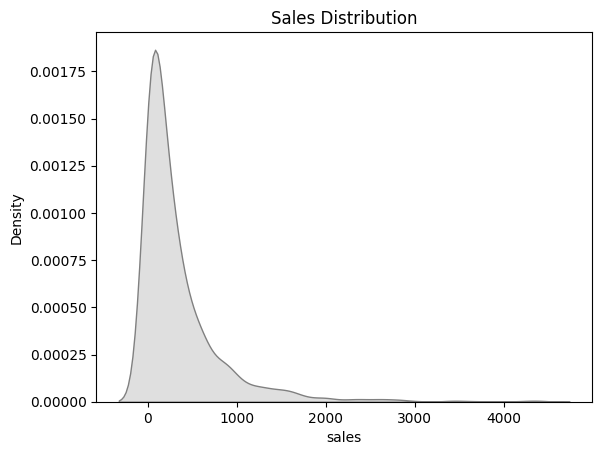

In [95]:
sns.kdeplot(data = df_sales,
            x = "sales",
            fill = True,
            color = "grey")
plt.title("Sales Distribution", fontsize = 12)
plt.show()

CORRELATION MATRIX

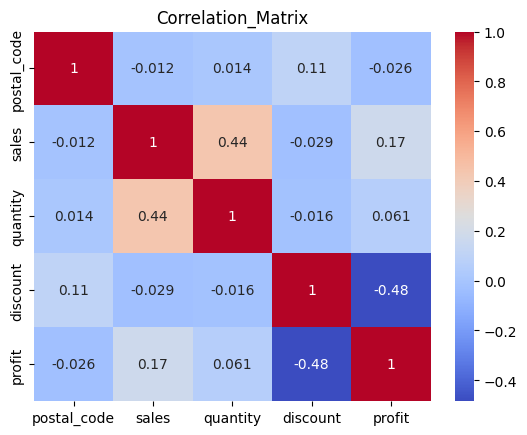

In [96]:
corr = df_sales.corr(numeric_only=True)
sns.heatmap(corr,
            annot = True,
            cmap = "coolwarm")
plt.title("Correlation_Matrix")
plt.show()

# VISUALIZATIONS

SALES BY REGION

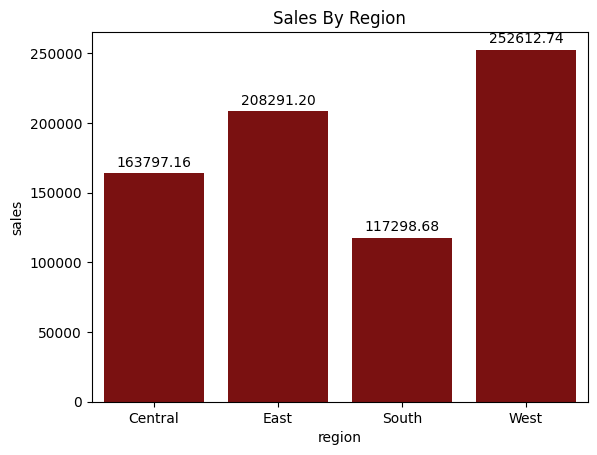

In [97]:
ax = sns.barplot(data = df_sales,
            x = "region",
            y = "sales",
            color = "darkred",
           errorbar=None,
                estimator = "sum")
for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)
plt.title("Sales By Region")
plt.show()

PROFIT BY REGION

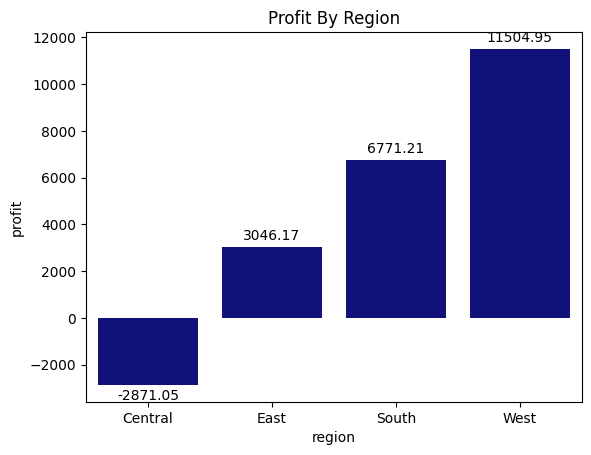

In [98]:
ax = sns.barplot(data = df_sales,
            x = "region",
            y = "profit",
            color = "darkblue",
           errorbar=None,
                estimator = "sum")
for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)
plt.title("Profit By Region")
plt.show()

SALES BY SUB CATEGORY

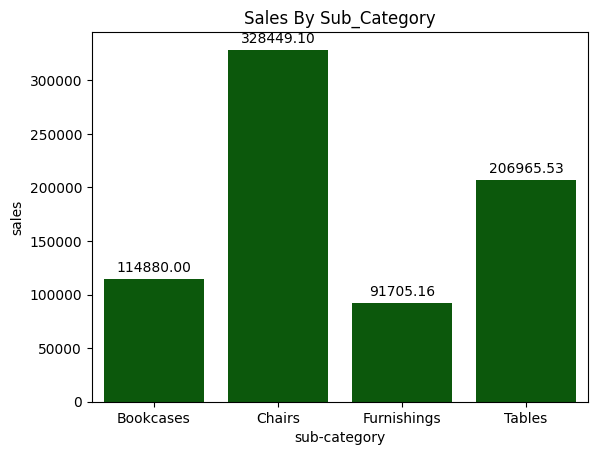

In [99]:
ax = sns.barplot(data = df_sales,
            x = "sub-category",
            y = "sales",
            color = "darkgreen",
           errorbar=None,
                estimator = "sum")
for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)
plt.title("Sales By Sub_Category")
plt.show()

PROFIT BY SUB CATEGORY

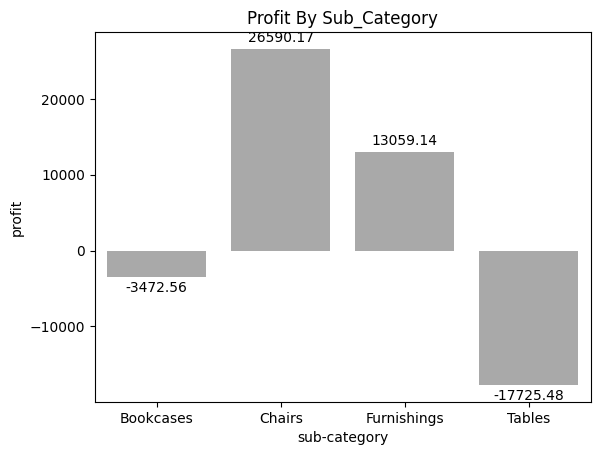

In [100]:
ax = sns.barplot(data = df_sales,
            x = "sub-category",
            y = "profit",
            color = "darkgrey",
           errorbar=None,
            estimator = "sum")
for container in ax.containers:
    ax.bar_label(container, fmt = "%.2f", padding = 3)
plt.title("Profit By Sub_Category")
plt.show()

SCATTER PLOT

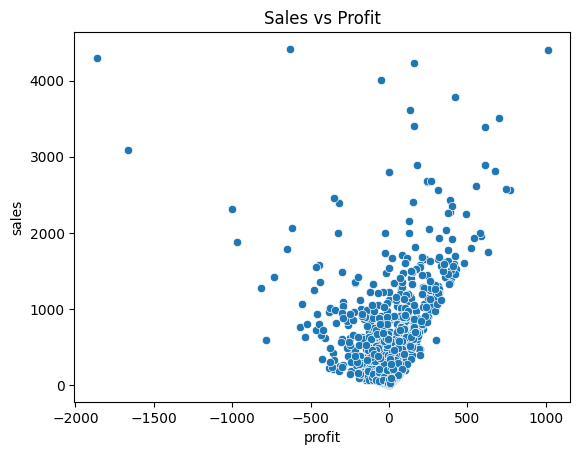

In [101]:
sns.scatterplot(data = df_sales,
                x = "profit",
                y = "sales",
                alpha = 1)
plt.title("Sales vs Profit")
plt.show()

BOX PLOT

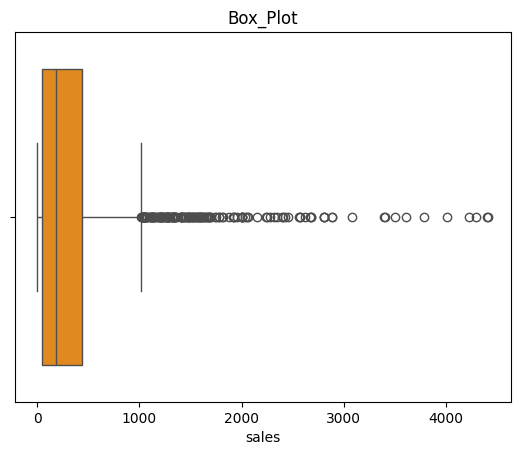

In [102]:
sns.boxplot(data = df_sales,
            x = "sales",
           color = "darkorange")
plt.title("Box_Plot")
plt.show()

# TRANSFORM THE DAILY SALES TO MONTHLY SALES
The transaction-level data are converted into a monthly time series by summing sales within each month.
This aggregation reduces transaction-level noise and allows the model to focus on monthly sales patterns.


In [103]:
monthly_sales = df_sales.groupby(pd.Grouper(key = "order_date", freq = "ME"))["sales"].sum().reset_index()

In [104]:
monthly_sales

,order_date,sales
0,2014-01-31,6242.5250
1,2014-02-28,1839.6580
2,2014-03-31,14573.9560
3,2014-04-30,7944.8370
4,2014-05-31,6912.7870
5,2014-06-30,13206.1256
6,2014-07-31,10821.0510
7,2014-08-31,7320.3465
8,2014-09-30,23816.4808
9,2014-10-31,12304.2470


MONTHLY_SALES TREND OVER TIME

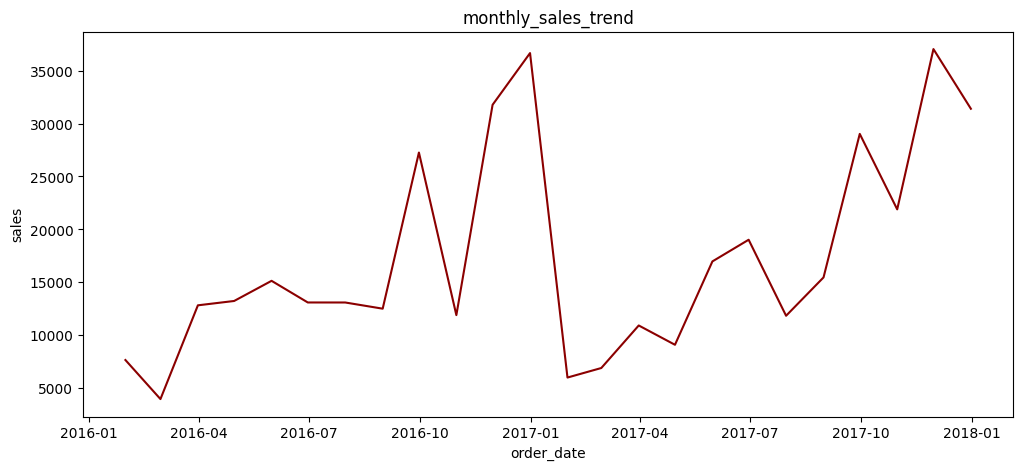

In [149]:
plt.figure(figsize = (12,5))
sns.lineplot(data = monthly_sales,
             x = "order_date",
             y = "sales",
             errorbar=None,
             color = "darkred")
plt.title("monthly_sales_trend")
plt.show()
             

# CALENDER FEATURES
Several calender features were created to capture seasonality, and long terms trends.

In [150]:
monthly_sales["year"] = monthly_sales["order_date"].dt.year
monthly_sales["month"] = monthly_sales["order_date"].dt.month
monthly_sales["quarter"] = monthly_sales["order_date"].dt.quarter
monthly_sales["dayofweek"] = monthly_sales["order_date"].dt.dayofweek

# FEATURE ENGENEERING 
Several time-series features were created from historical sales.

In [107]:
monthly_sales["sales_lag1"] = monthly_sales["sales"].shift(1)
monthly_sales["sales_lag2"] = monthly_sales["sales"].shift(2)
monthly_sales["sales_lag3"] = monthly_sales["sales"].shift(3)
monthly_sales["sales_lag12"] = monthly_sales["sales"].shift(12)
monthly_sales["sales_lag24"] = monthly_sales["sales"].shift(24)
monthly_sales["sales_yoy_growth"] = (monthly_sales["sales"].shift(12)/ monthly_sales["sales"].shift(24)-1)
monthly_sales["sales_mean3"] = monthly_sales["sales"].shift(1).rolling(3).mean()
monthly_sales["sales_std3"] = monthly_sales["sales"].shift(1).rolling(3).std()

In [108]:
monthly_sales = monthly_sales.dropna().reset_index(drop = True)

In [109]:
monthly_sales

,order_date,sales,year,month,quarter,dayofweek,sales_lag1,sales_lag2,sales_lag3,sales_lag12,sales_lag24,sales_yoy_growth,sales_mean3,sales_std3
0,2016-01-31,7622.7430,2016,1,1,6,23085.8192,30880.8325,12026.6235,11739.9416,6242.5250,0.880640,21997.758400,9474.080772
1,2016-02-29,3925.5510,2016,2,1,0,7622.7430,23085.8192,30880.8325,3134.3740,1839.6580,0.703781,20529.798233,11837.846687
2,2016-03-31,12801.0920,2016,3,1,3,3925.5510,7622.7430,23085.8192,12499.7830,14573.9560,-0.142321,11544.704400,10164.413672
3,2016-04-30,13212.0900,2016,4,2,5,12801.0920,3925.5510,7622.7430,10475.6985,7944.8370,0.318554,8116.462000,4458.320967
4,2016-05-31,15119.8350,2016,5,2,1,13212.0900,12801.0920,3925.5510,9374.9505,6912.7870,0.356175,9979.577667,5246.966647
5,2016-06-30,13070.5720,2016,6,2,3,15119.8350,13212.0900,12801.0920,7714.1790,13206.1256,-0.415864,13711.005667,1237.267112
6,2016-07-31,13068.5190,2016,7,3,6,13070.5720,15119.8350,13212.0900,13674.4200,10821.0510,0.263687,13800.832333,1144.479297
7,2016-08-31,12483.2323,2016,8,3,2,13068.5190,13070.5720,15119.8350,9638.5922,7320.3465,0.316685,13752.975333,1183.735640
8,2016-09-30,27262.8809,2016,9,3,4,12483.2323,13068.5190,13070.5720,26273.0230,23816.4808,0.103145,12874.107767,338.509640
9,2016-10-31,11872.5770,2016,10,4,0,27262.8809,12483.2323,13068.5190,12026.6235,12304.2470,-0.022563,17604.877400,8369.194336


# DEFINE X AND  Y VARIABLE

In [110]:
X = monthly_sales.drop(columns = ["order_date","sales","quarter","dayofweek"], axis =1)
Y = monthly_sales["sales"]

 # SPLIT DATA
 Because this is a time-series forecasting problem, the data were divided chronologically rather than randomly.

In [111]:
split = int(len(monthly_sales)*0.8)

In [112]:
x_train = X.iloc[:split]
x_test = X.iloc[split:]
y_train = Y.iloc[:split]
y_test = Y.iloc[split:]

In [113]:
x_train.shape, x_test.shape

((19, 10), (5, 10))

In [114]:
y_train.shape, y_test.shape

((19,), (5,))

# NAIVE MODEL
A naive model was established as a refrence to our main XGBoost model.Naive model is build on a concept of our lag variable is equals to our next predictions.

In [115]:
naive_ypred = x_test["sales_lag1"]

NAIVE EVALUATION

In [116]:
naive_r2 = r2_score(y_test, naive_ypred)
naive_r2

-0.7962694397030394

In [117]:
naive_mae = mean_absolute_error(y_test, naive_ypred)
naive_mae

9036.243360000002

In [118]:
naive_mse = mean_squared_error(y_test, naive_ypred)
naive_mse

102183781.0200541

In [119]:
naive_rmse = np.sqrt(naive_mse)
naive_rmse

np.float64(10108.599359953589)

# XGBoost Model
XGBoost was selected because it can capture nonlinear relationships between historical sales, seasonal patterns, and other engineered features.

In [120]:
xgb_model = XGBRegressor(random_state = 42)

# HYPERPARAMETER TURNINGS

In [121]:
params = {"n_estimators":[100,300,500],
          "max_depth":[2,3,5],
          "learing_rate":[0.01,0.03,0.05],
          "subsample":[0.6,0.7,0.8],
          "colsample":[0.6,0.7,0.8]}

# TIME SERIES CROSS VALIDATIONS

In [122]:
tscv = TimeSeriesSplit(n_splits = 5)

# GRIDSEARCH CV

In [123]:
grid = GridSearchCV(estimator = xgb_model,
                    cv = tscv,
                    param_grid= params,
                    scoring = "neg_mean_squared_error")

In [124]:
import warnings
warnings.filterwarnings("ignore")

In [125]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample': [0.6, 0.7, ...], 'learing_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versi

In [126]:
grid.best_params_

{'colsample': 0.6,
 'learing_rate': 0.01,
 'max_depth': 2,
 'n_estimators': 500,
 'subsample': 0.8}

In [127]:
xgb_model = grid.best_estimator_

# PREDICT X_TRAIN,X_TEST

In [128]:
ypred_xtrain = xgb_model.predict(x_train)
ypred_xtest = xgb_model.predict(x_test)

# MODELS EVALUATIONS
The model was evaluated using:

* R² - measures the proportion of variation in sales explained by the model.
* MAE -measures the average absolute forecasting error.
* RMSE - measures the magnitude of forecasting errors while giving greater weight to large errors.

The final model achieved an R² of approximately 0.41 (41%) on the test set.

This indicates that the model explains approximately 41% of the variation in monthly sales in the test period.

In [129]:
r2_xtrain = r2_score(y_train, ypred_xtrain)
r2_xtrain

0.9999999999999626

In [130]:
mae_xtrain = mean_absolute_error(y_train, ypred_xtrain)
mae_xtrain

0.0011529810854211207

In [131]:
mse_xtrain = mean_squared_error(y_train, ypred_xtrain)
mse_xtrain

2.637074623223461e-06

In [132]:
rmse_xtrain = np.sqrt(mse_xtrain)
rmse_xtrain

np.float64(0.0016239072089326598)

X_TEST EVALUATIONS

In [133]:
r2_xtest = r2_score(y_test, ypred_xtest)
r2_xtest

0.4144721377570596

In [134]:
mae_xtest = mean_absolute_error(y_test, ypred_xtest)
mae_xtest

4619.590998750001

In [135]:
mse_xtest = mean_squared_error(y_test, ypred_xtest)
mse_xtest

33308728.375663064

In [136]:
rmse_test = np.sqrt(mse_xtest)
rmse_test

np.float64(5771.371446689518)

# MODEL COMPARISONS

In [148]:
comparison = pd.DataFrame({"Model":["Naive_Model","XGBoost_Model"],
                           "R2":[-0.79626,0.41447],
                           "MAE":[9036.2434,4619.5909],
                           "MSE":[102183781.020,33308728.37566],
                           "RMSE":[10108.599,5771.371]})
comparison

,Model,R2,MAE,MSE,RMSE
0,Naive_Model,-0.79626,9036.2434,1.021838e+08,10108.599
1,XGBoost_Model,0.41447,4619.5909,3.330873e+07,5771.371


# FEATURE IMPORTANCE
Feature importance was examined to understand which variables contributed most to the XGBoost predictions.

The most important features were:

1. month -approximately 54.9%
2. sales_lag12 -approximately 20.2%
3. sales_mean3 -approximately 11.3%
4. sales_lag1 -approximately 6.3%

The results suggest that seasonality and the previous year’s sales pattern are the dominant signals in the forecasting problem.

In particular, the high importance of sales_lag12 indicates that sales in the same month of the previous year contain substantial information about future monthly sales.


In [138]:
importances = xgb_model.feature_importances_

In [139]:
importance = pd.DataFrame({"Feature": x_train.columns,
                         "Importance": importances}).sort_values(by = "Importance", ascending = False)
importance

,Feature,Importance
1,month,0.548611
5,sales_lag12,0.201900
8,sales_mean3,0.113309
2,sales_lag1,0.063270
3,sales_lag2,0.025275
4,sales_lag3,0.024162
6,sales_lag24,0.015470
7,sales_yoy_growth,0.007088
0,year,0.000773
9,sales_std3,0.000143


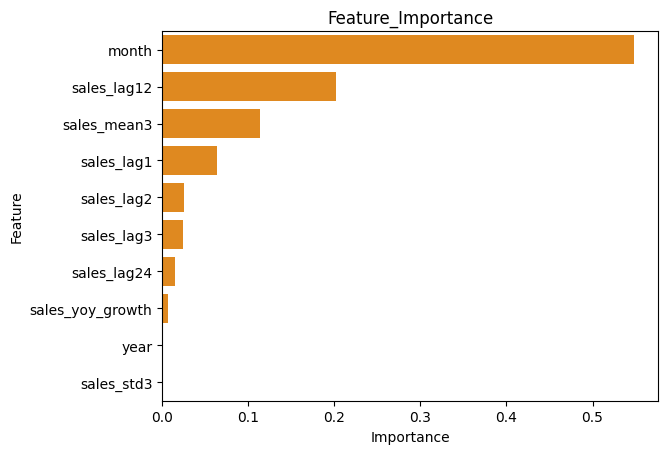

In [140]:
sns.barplot(data = importance,
            x = "Importance",
            y = "Feature",
            errorbar=None,
            color = "darkorange")
plt.title("Feature_Importance")
plt.show()

# ACTUAL VS PREDICTIONS GRAPH

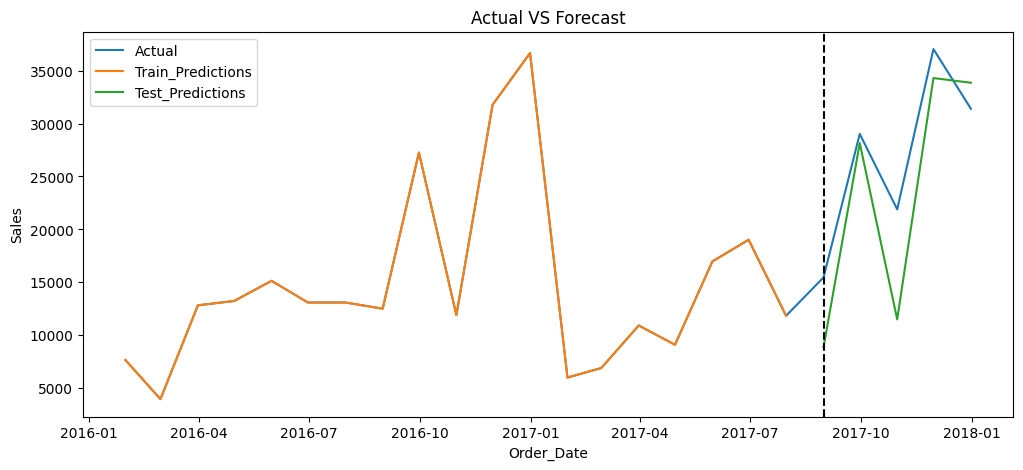

In [141]:
plt.figure(figsize = (12,5))
plt.plot(monthly_sales["order_date"], monthly_sales["sales"], label = "Actual")
plt.plot(monthly_sales["order_date"].iloc[:split], ypred_xtrain, label ="Train_Predictions")
plt.plot(monthly_sales["order_date"].iloc[split:], ypred_xtest, label = "Test_Predictions")
plt.xlabel("Order_Date")
plt.ylabel("Sales")
plt.title("Actual VS Forecast")
split_date = monthly_sales["order_date"].iloc[split]

plt.axvline(x = split_date, color = "black", linestyle = "--")
plt.legend()
plt.show()

In [143]:
monthly_sales.columns

Index(['order_date', 'sales', 'year', 'month', 'quarter', 'dayofweek',
       'sales_lag1', 'sales_lag2', 'sales_lag3', 'sales_lag12', 'sales_lag24',
       'sales_yoy_growth', 'sales_mean3', 'sales_std3'],
      dtype='object')

# RECURSIVE FORECASTING
After evaluating the model, a recursive forecasting approach was used to generate forecasts for the next 12 months.

In [144]:
future_predictions =[]

last_data = monthly_sales.copy()

for i in range(12):
    last_row = last_data.iloc[-1:]
    next_month = last_row["order_date"] + pd.DateOffset(months = 1)

    new_row = pd.DataFrame({
    "order_date": next_month,
    "year": next_month.dt.year,
    "month": next_month.dt.month,
    "sales_lag1": last_data["sales"].iloc[-1],
    "sales_lag2": last_data["sales"].iloc[-2],
    "sales_lag3": last_data["sales"].iloc[-3],
    "sales_lag12": last_data["sales"].iloc[-12],
    "sales_lag24": last_data["sales"].iloc[-24],
    "sales_yoy_growth": last_data["sales"].iloc[-12]/last_data["sales"].iloc[-24],
    "sales_mean3": last_data["sales"].iloc[-3:].mean(),
     "sales_std3": last_data["sales"].iloc[-3:].std()
        })

    x_new = new_row.drop(columns = "order_date",axis =1)

    pred = xgb_model.predict(x_new)[0]

    new_row["sales"] = pred

    future_predictions.append(new_row)

    last_data = pd.concat([last_data, new_row], ignore_index = True)

    future_df = pd.concat(future_predictions, ignore_index = True)
    
                                             

In [145]:
future_df

,order_date,year,month,sales_lag1,sales_lag2,sales_lag3,sales_lag12,sales_lag24,sales_yoy_growth,sales_mean3,sales_std3,sales
0,2018-01-31,2018,1,31407.466800,37056.715000,21884.068200,5964.0320,7622.7430,0.782400,30116.083333,7668.315080,7586.235840
1,2018-02-28,2018,2,7586.235840,31407.466800,37056.715000,6866.3374,3925.5510,1.749140,25350.139213,15641.154005,6858.173340
2,2018-03-28,2018,3,6858.173340,7586.235840,31407.466800,10893.4448,12801.0920,0.850978,15283.958660,13968.112070,10870.621094
3,2018-04-28,2018,4,10870.621094,6858.173340,7586.235840,9065.9581,13212.0900,0.686187,8438.343424,2137.638825,11250.435547
4,2018-05-28,2018,5,11250.435547,10870.621094,6858.173340,16957.5582,15119.8350,1.121544,9659.743327,2433.651690,19676.626953
5,2018-06-28,2018,6,19676.626953,11250.435547,10870.621094,19008.5867,13070.5720,1.454304,13932.561198,4978.130503,20997.898438
6,2018-07-28,2018,7,20997.898438,19676.626953,11250.435547,11813.0220,13068.5190,0.903930,17308.320312,5287.713632,9381.131836
7,2018-08-28,2018,8,9381.131836,20997.898438,19676.626953,15441.8740,12483.2323,1.237009,16685.219076,6359.929826,13329.815430
8,2018-09-28,2018,9,13329.815430,9381.131836,20997.898438,29028.2060,27262.8809,1.064752,14569.615234,5906.787980,29480.533203
9,2018-10-28,2018,10,29480.533203,13329.815430,9381.131836,21884.0682,11872.5770,1.843245,17397.160156,10649.129245,19272.279297


In [146]:
monthly_sales["order_date"].max()

Timestamp('2017-12-31 00:00:00')

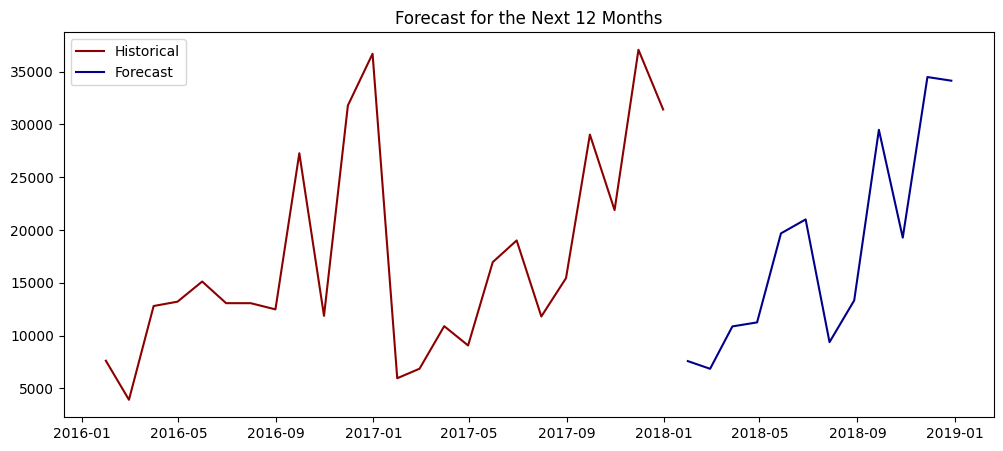

In [151]:
plt.figure(figsize = (12,5))
plt.plot(monthly_sales["order_date"], monthly_sales["sales"], label = "Historical", color = "darkred")
plt.plot(future_df["order_date"], future_df["sales"], label = "Forecast", color = "darkblue")
plt.title("Forecast for the Next 12 Months")
plt.legend()
plt.show()

# KEY FINDINGS
The analysis shows that monthly retail sales contain a strong seasonal component.

The importance of month and sales_lag12 suggests that sales patterns are strongly related to the time of year and to sales during the same month in the previous year.

The XGBoost model achieved an R² of approximately 41% on the test data, demonstrating that the engineered time-series features provide useful predictive information.

# Limitations

The model uses historical sales and calendar-based features only. It does not include external factors such as prices, promotions, holidays, economic conditions, or changes in customer behaviour.

# CONCLUSION
This project demonstrates how XGBoost can be applied to monthly retail sales forecasting using time-series feature engineering.
The results highlight the importance of seasonality and year-over-year historical patterns in predicting retail sales.